# **Pair Trading Strategy**

## Finding Cointegrated stocks

In [43]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

In [23]:
# Pairs to test
pairs = [
    ('KO','PEP'), # Cola and Pepsi
    ('XOM','CVX'), # Exxon vs Chevron
    ('GS','MS'), # Goldman Sach vs Morgan Stanley
    ('ADBE','MSFT')# Adobe vs Microsoft
]

In [33]:
gld = yf.download([p for pair in pairs for p in pair],start='2015-01-01', end='2023-01-01')['Close']

[*********************100%***********************]  8 of 8 completed


In [34]:
gld.head()

Ticker,ADBE,CVX,GS,KO,MS,MSFT,PEP,XOM
Date,,,,,,,,
2015-01-02,72.339996,69.529388,155.555191,29.580008,28.558187,39.767681,67.283463,57.533428
2015-01-05,71.980003,66.750198,150.698318,29.580008,27.665510,39.401993,66.777634,55.959194
2015-01-06,70.529999,66.719292,147.649796,29.804642,26.868740,38.823677,66.271782,55.661724
2015-01-07,71.110001,66.663734,149.850204,30.176680,27.252361,39.316944,68.209648,56.225704
2015-01-08,72.919998,68.189201,152.242615,30.541674,27.658123,40.473591,69.449287,57.161568


In [35]:
gld.columns = gld.columns.get_level_values(0)

In [36]:
print("Testing pairs for cointegration...\n")
for s1,s2 in pairs:
    try:
        p1 = gld[s1].dropna()
        p2 = gld[s2].dropna()
        p1,p2 = p1.align(p2,join='inner')
        score, pvalue, _ = coint(p1,p2)
        result = 'Cointegrated' if pvalue < 0.05 else 'Not Cointegrated'
        print(f'{s1} vs {s2} : p-value = {pvalue:.4f} {result}')
    except Exception as e:
        print(f'{s1} vs {s2}: Error - {e}')

Testing pairs for cointegration...

KO vs PEP : p-value = 0.0096 Cointegrated
XOM vs CVX : p-value = 0.8368 Not Cointegrated
GS vs MS : p-value = 0.0174 Cointegrated
ADBE vs MSFT : p-value = 0.8812 Not Cointegrated


### Calculating Spread

Working with Ko And Pep.

Raw difference between price is meaningless because one can be naturally more expensive.

We need to find the real relationship, how many dollars KO equals one dollar of PEP (The hedge ratio)

### Hedge Ratio

For every 1 share of PEP i trade, how many share of KO do i trade to stay balanced

In [41]:
data = yf.download(['KO','PEP'],start='2015-01-01', end='2023-01-01')['Close']
data.columns = data.columns.get_level_values(0)
data = data.dropna()
data.head()

[*********************100%***********************]  2 of 2 completed


Ticker,KO,PEP
Date,,
2015-01-02,29.580008,67.283463
2015-01-05,29.580008,66.777634
2015-01-06,29.804642,66.271782
2015-01-07,30.176680,68.209648
2015-01-08,30.541674,69.449287


In [45]:
pep = data['PEP']
ko = data['KO']

In [50]:
# Calculate hedge ratio using linear regression
pep_const = add_constant(pep)
model = OLS(ko, pep_const).fit()
hedge_ratio = model.params['PEP']
print(f"Hedge Ratio: {hedge_ratio:.4f}")

Hedge Ratio: 0.3012


In [51]:
# calculate spread
spread = ko - hedge_ratio * pep

In [52]:
spread.head()

Date
2015-01-02    9.317059
2015-01-05    9.469393
2015-01-06    9.846369
2015-01-07    9.634803
2015-01-08    9.626470
dtype: float64

In [55]:
spread.describe()

count    2014.000000
mean        8.618555
std         1.811534
min         2.030792
25%         7.556137
50%         8.448992
75%         9.763789
max        13.422476
dtype: float64

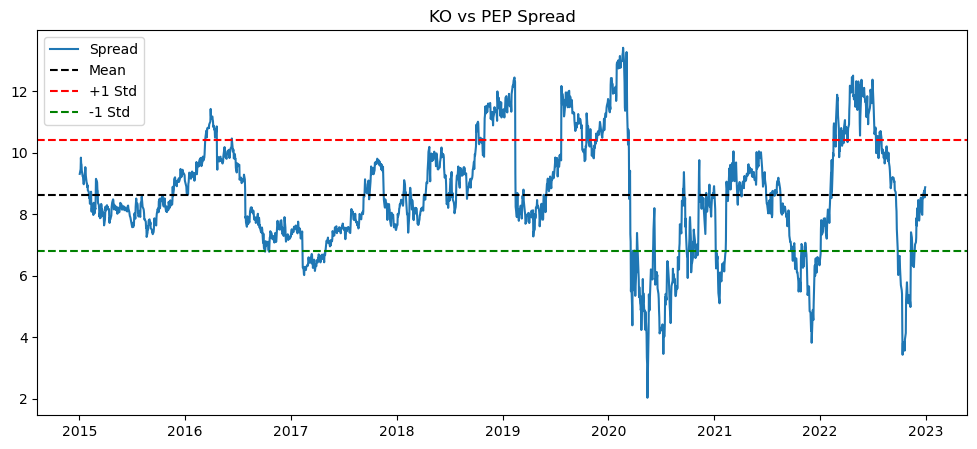

In [57]:
# Plot of spread
plt.figure(figsize=(12,5))
plt.plot(spread, label='Spread')
plt.axhline(spread.mean(), color='black', linestyle='--', label='Mean')
plt.axhline(spread.mean() + spread.std(), color='red', linestyle='--', label='+1 Std')
plt.axhline(spread.mean() - spread.std(), color='green', linestyle='--', label='-1 Std')
plt.title('KO vs PEP Spread')
plt.legend()
plt.show()

- **spread crosses above red line** -> KO too expensive relative to PEP -> sell KO buy PEP
- **spread crosses below green line** -> KO too cheap relative to PEP -> Buy KO sell PEP
- **spread returns to mean** -> close trade -> take profit

Side Note: Relationship broke temporarily in 2020 during COVID, but returns to fixed average which confirms cointegration

## **Define entry and exit strategy**

We use Z-score to decide when to trade

The Z-score answers "How many standard deviations away from the mean is the spread right now"

Z-score = (spread-mean)/standard deviation

* Z-score = 0 -> spread is at it's mean -> no trade 
* Z-score = 2 -> spread is 2 deviations above mean -> too high -> sell KO and buy PEP
* Z-score = -2 -> spread is 2 deviations below mean -> too low -> buy KO and sell PEP

### Four Rules
- Entry Long -> Z-score < -1  (Buy KO, Sell PEP)
- Entry Short -> Z-score > 1  (Sell KO, buy PEP)
- Exit Long -> Z-score >= 0  (Close the long trade)
- Exit Short -> Z-score <= 0  (Close the short trade)

In [60]:
# Download data (pre covid period)
data = yf.download(['KO','PEP'], start='2015-01-01', end='2020-01-01')['Close']
data.columns = data.columns.get_level_values(0)
data = data.dropna()
data.head()

[*********************100%***********************]  2 of 2 completed


Ticker,KO,PEP
Date,,
2015-01-02,29.580013,67.283478
2015-01-05,29.580013,66.777618
2015-01-06,29.804644,66.271767
2015-01-07,30.176674,68.209625
2015-01-08,30.541683,69.449295


In [62]:
ko = data['KO']
pep = data['PEP']

In [63]:
# calculate hedge ratio
pep_const = add_constant(pep)
model = OLS(ko,pep_const).fit()
hedge_ratio = model.params['PEP']
print(f"Hedge Ratio: {hedge_ratio:.4f}")

Hedge Ratio: 0.3401


In [64]:
# calculate spread
spread = ko - pep * hedge_ratio

In [68]:
# calculate Z-score
zscore = (spread-spread.mean())/spread.std()

In [69]:
# Define Signals
longEntry = zscore < -1 # buy KO, sell PEP
shortEntry = zscore > 1 # buy PEP, sell KO
longExit = zscore >= 0 # close long
shortExit = zscore <= 0 # close short

In [71]:
# Build position series
# 1 = long spread, -1 = short spread, 0 = no position
position = np.zeros(len(zscore))

In [72]:
for t in range(1, len(zscore)):
    if position[t-1] == 0:  # not in a trade
        if longEntry.iloc[t]:
            position[t] = 1
        elif shortEntry.iloc[t]:
            position[t] = -1
    elif position[t-1] == 1:  # currently long
        if longExit.iloc[t]:
            position[t] = 0
        else:
            position[t] = 1
    elif position[t-1] == -1:  # currently short
        if shortExit.iloc[t]:
            position[t] = 0
        else:
            position[t] = -1

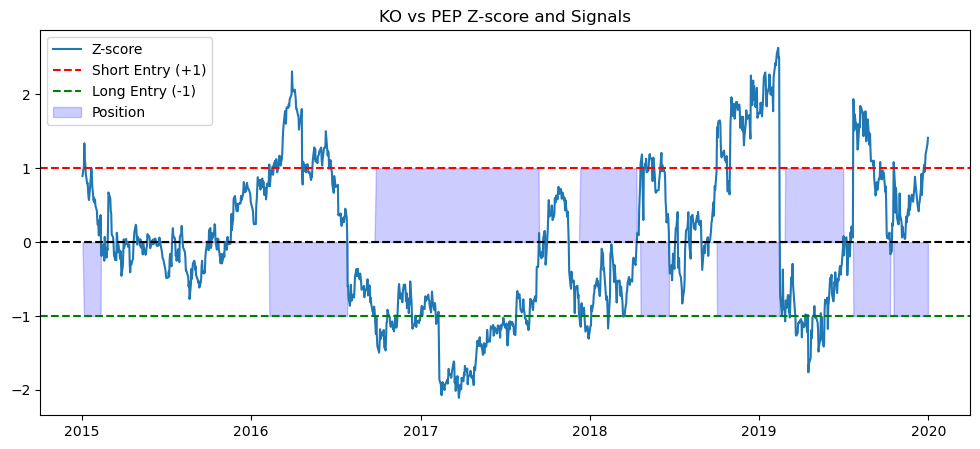

Total long days:  414
Total short days: 387
Total flat days:  457


In [73]:
# Plot zscore and signals
plt.figure(figsize=(12,5))
plt.plot(zscore.index, zscore, label='Z-score')
plt.axhline(0, color='black', linestyle='--')
plt.axhline(1, color='red', linestyle='--', label='Short Entry (+1)')
plt.axhline(-1, color='green', linestyle='--', label='Long Entry (-1)')
plt.fill_between(zscore.index, position, 0, alpha=0.2, 
                  color='blue', label='Position')
plt.title('KO vs PEP Z-score and Signals')
plt.legend()
plt.show()

print(f"Total long days:  {(position == 1).sum()}")
print(f"Total short days: {(position == -1).sum()}")
print(f"Total flat days:  {(position == 0).sum()}")

## calculating actual returns and performance

Sharpe Ratio:              0.4269
Max Drawdown:              -3.79%
Max Drawdown Duration:     313 days
Total Return:              9.26%


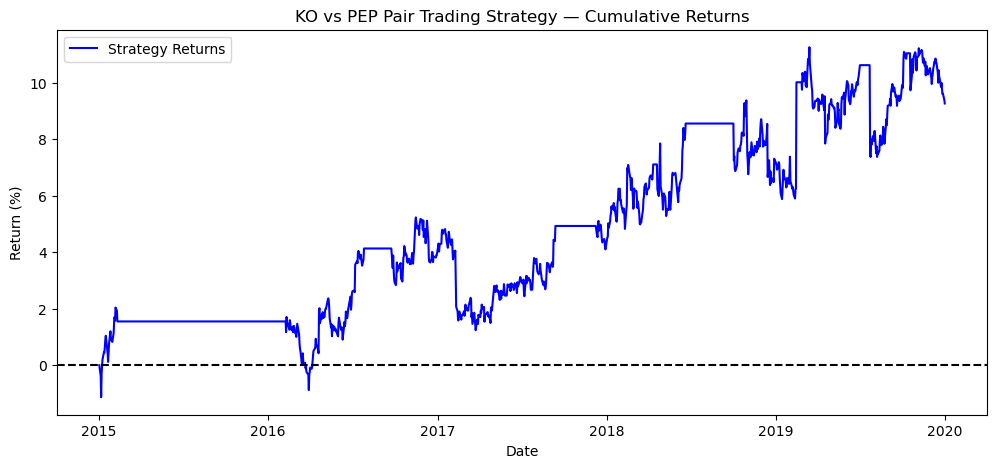

In [74]:
# Daily returns for each stock
koRet  = ko.pct_change().fillna(0)
pepRet = pep.pct_change().fillna(0)

# Net daily strategy returns
# When long:  buy KO, sell PEP  → koRet - pepRet
# When short: sell KO, buy PEP  → pepRet - koRet
dailyRet = np.where(
    position == 1,  (koRet - pepRet) / 2,
    np.where(
    position == -1, (pepRet - koRet) / 2,
    0))

# Cumulative returns
cumRet = (1 + dailyRet).cumprod() - 1

# Performance metrics
sharpeRatio = np.sqrt(252) * np.mean(dailyRet) / np.std(dailyRet)

# Max drawdown
def calculateMaxDD(cumret):
    highwatermark = np.zeros(cumret.shape)
    drawdown = np.zeros(cumret.shape)
    drawdownduration = np.zeros(cumret.shape)
    for t in np.arange(1, cumret.shape[0]):
        highwatermark[t] = np.maximum(highwatermark[t-1], cumret[t])
        drawdown[t] = (1+cumret[t])/(1+highwatermark[t])-1
        if drawdown[t] == 0:
            drawdownduration[t] = 0
        else:
            drawdownduration[t] = drawdownduration[t-1]+1
    maxDD  = np.min(drawdown)
    maxDDD = np.max(drawdownduration)
    return maxDD, maxDDD

maxDD, maxDDD = calculateMaxDD(cumRet)

# Print results
print(f"Sharpe Ratio:              {sharpeRatio:.4f}")
print(f"Max Drawdown:              {maxDD*100:.2f}%")
print(f"Max Drawdown Duration:     {maxDDD:.0f} days")
print(f"Total Return:              {cumRet[-1]*100:.2f}%")

# Plot cumulative returns
plt.figure(figsize=(12,5))
plt.plot(data.index, cumRet * 100, label='Strategy Returns', color='blue')
plt.axhline(0, color='black', linestyle='--')
plt.title('KO vs PEP Pair Trading Strategy — Cumulative Returns')
plt.ylabel('Return (%)')
plt.xlabel('Date')
plt.legend()
plt.show()